---
## Tarea Parte I

In [1]:
import sys
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    MinMaxScaler,
    PowerTransformer,
    RobustScaler,
    StandardScaler,
)

cartera = pd.read_parquet("src/cartera_q1_2026_final.parquet")
cartera.columns

Index(['id_poliza', 'num_poliza', 'nombre', 'apellido_paterno',
       'apellido_materno', 'rfc', 'edad', 'sexo', 'estado_civil', 'ocupacion',
       'ramo', 'plan', 'fecha_emision', 'fecha_inicio_vigencia',
       'fecha_fin_vigencia', 'num_renovaciones', 'status_poliza',
       'motivo_baja', 'canal_venta', 'marca_vehiculo', 'modelo_vehiculo',
       'tipo_vehiculo', 'suma_asegurada', 'deducible', 'prima_neta',
       'prima_total', 'forma_pago', 'agente_id', 'estado', 'municipio',
       'codigo_postal', 'nombre_agente', 'region', 'tipo_agente',
       'comision_pct', 'n_siniestros', 'monto_reclamado', 'monto_pagado',
       'tiene_abierto', 'tipo_principal', 'prima_mensual', 'loss_ratio',
       'comision_est', 'nivel_riesgo', 'anio_emision', 'mes_emision',
       'trimestre', 'segmento_prima_fijo', 'cuartil_prima', 'cod_ramo',
       'anio_poliza', 'ramo_desde_codigo'],
      dtype='str')

In [2]:
cartera["ramo"].value_counts()

ramo
GMM                      22531
Autos                    14752
Vida                      7510
Accidentes Personales     5207
Name: count, dtype: int64

In [3]:
cartera.groupby("ramo").agg(
    polizas=("id_poliza", "count"),
    prima_promedio=("prima_total", "mean"),
    siniestros_promedio=("n_siniestros", "mean"),
    monto_reclamado=("monto_reclamado", "mean"),
    loss_ratio=("loss_ratio", "mean")
).round(2)

,polizas,prima_promedio,siniestros_promedio,monto_reclamado,loss_ratio
ramo,,,,,
Accidentes Personales,5207,4797.52,0.35,12990.09,0.41
Autos,14752,17206.04,0.36,13473.50,0.25
GMM,22531,32445.18,0.36,13403.79,0.20
Vida,7510,60496.95,0.36,12780.06,0.12


Se seleccionó el ramo de Autos debido a que cuenta con un número suficiente de observaciones (14,752 pólizas) y una amplia variedad de variables relacionadas con las características del asegurado, del vehículo y de la póliza. Esto permite realizar un análisis exploratorio completo y construir modelos predictivos con variables explicativas relevantes para interpretar el comportamiento de la prima y la ocurrencia de siniestros.

In [9]:
class AnalizadorRamo:

    def __init__(self, dataframe, nombre_ramo):
        self.df_completo = dataframe
        self.ramo = nombre_ramo
        self.df_ramo = dataframe[dataframe['ramo'] == nombre_ramo].copy()

    # 1. Estadísticas generales
    def calcular_estadisticas(self):

        estadisticas = self.df_ramo.groupby('ramo').agg(
            numero_polizas=('id_poliza', 'nunique'),
            prima_total=('prima_total', 'sum'),
            prima_promedio=('prima_total', 'mean'),
            siniestros_totales=('n_siniestros', 'sum'),
            monto_reclamado_total=('monto_reclamado', 'sum'),
            monto_pagado_total=('monto_pagado', 'sum'),
            siniestro_promedio=('monto_pagado', 'mean'),
            suma_asegurada_promedio=('suma_asegurada', 'mean'),
            edad_promedio=('edad', 'mean')
        ).round(2)

        return estadisticas

    # 2. Estadísticas descriptivas
    def estadisticas_numericas(self):

        variables = [
            'edad',
            'prima_total',
            'prima_neta',
            'suma_asegurada',
            'n_siniestros',
            'monto_reclamado',
            'monto_pagado',
            'loss_ratio'
        ]

        return self.df_ramo[variables].describe().round(2)

    # 3. Distribuciones
    def graficar(self):

        self.df_ramo['anio_inicio'] = pd.to_datetime(
            self.df_ramo['fecha_inicio_vigencia']
        ).dt.year

        fig, axes = plt.subplots(3, 3, figsize=(18, 15))
        fig.suptitle(f'Análisis Exploratorio - {self.ramo}', fontsize=18)

        # Sexo
        self.df_ramo['sexo'].value_counts().plot(
            kind='bar',
            ax=axes[0,0],
            color='skyblue',
            edgecolor='black'
        )
        axes[0,0].set_title('Sexo')

        # Edad
        axes[0,1].hist(
            self.df_ramo['edad'],
            bins=15,
            color='salmon',
            edgecolor='black'
        )
        axes[0,1].set_title('Edad')

        # Año de inicio
        axes[0,2].hist(
            self.df_ramo['anio_inicio'],
            bins=6,
            color='lightgreen',
            edgecolor='black'
        )
        axes[0,2].set_title('Año Inicio Vigencia')

        # Plan
        self.df_ramo['plan'].value_counts().plot(
            kind='bar',
            ax=axes[1,0],
            color='orchid',
            edgecolor='black'
        )
        axes[1,0].set_title('Plan')

        # Prima Total
        axes[1,1].hist(
            self.df_ramo['prima_total'],
            bins=20,
            color='gold',
            edgecolor='black'
        )
        axes[1,1].set_title('Prima Total')

        # Número de siniestros
        axes[1,2].hist(
            self.df_ramo['n_siniestros'],
            bins=10,
            color='lightcoral',
            edgecolor='black'
        )
        axes[1,2].set_title('Número de Siniestros')

        # Tipo de vehículo
        self.df_ramo['tipo_vehiculo'].value_counts().plot(
            kind='bar',
            ax=axes[2,0],
            color='steelblue',
            edgecolor='black'
        )
        axes[2,0].set_title('Tipo de Vehículo')

        # Nivel de riesgo
        self.df_ramo['nivel_riesgo'].value_counts().plot(
            kind='bar',
            ax=axes[2,1],
            color='tomato',
            edgecolor='black'
        )
        axes[2,1].set_title('Nivel de Riesgo')

        # Top 10 marcas
        self.df_ramo['marca_vehiculo'].value_counts().head(10).plot(
            kind='bar',
            ax=axes[2,2],
            color='mediumpurple',
            edgecolor='black'
        )
        axes[2,2].set_title('Top 10 Marcas')

        plt.tight_layout()
        plt.show()

    # 4. Correlaciones
    def matriz_correlacion(self):

        columnas = [
            'edad',
            'prima_total',
            'prima_neta',
            'suma_asegurada',
            'n_siniestros',
            'monto_reclamado',
            'monto_pagado',
            'loss_ratio'
        ]

        correlacion = self.df_ramo[columnas].corr()

        plt.figure(figsize=(10,8))

        sns.heatmap(
            correlacion,
            annot=True,
            cmap='coolwarm',
            fmt='.2f'
        )

        plt.title('Matriz de Correlación')
        plt.show()

    # 5. Boxplots
    def boxplots(self):

        fig, axes = plt.subplots(2,2, figsize=(12,8))

        sns.boxplot(
            y=self.df_ramo['prima_total'],
            ax=axes[0,0]
        )
        axes[0,0].set_title('Prima Total')

        sns.boxplot(
            y=self.df_ramo['suma_asegurada'],
            ax=axes[0,1]
        )
        axes[0,1].set_title('Suma Asegurada')

        sns.boxplot(
            y=self.df_ramo['monto_pagado'],
            ax=axes[1,0]
        )
        axes[1,0].set_title('Monto Pagado')

        sns.boxplot(
            y=self.df_ramo['loss_ratio'],
            ax=axes[1,1]
        )
        axes[1,1].set_title('Loss Ratio')

        plt.tight_layout()
        plt.show()

    # 6. Detección de valores atípicos
    def detectar_outliers(self, columna):

        Q1 = self.df_ramo[columna].quantile(0.25)
        Q3 = self.df_ramo[columna].quantile(0.75)
        IQR = Q3 - Q1

        print(f"\nVariable: {columna}")
        print(f"Q1: {Q1}")
        print(f"Q3: {Q3}")
        print(f"IQR: {IQR}")

        # CASO ESPECIAL: IQR = 0
        if IQR == 0:
            print("⚠️ Distribución degenerada (muchos ceros). Usando percentil 95 en su lugar.")

            limite_superior = self.df_ramo[columna].quantile(0.95)
            limite_inferior = 0

        else:
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

        outliers = self.df_ramo[
            (self.df_ramo[columna] < limite_inferior) |
            (self.df_ramo[columna] > limite_superior)
        ]

        print(f"Outliers encontrados: {len(outliers)}")

        return outliers

    # 7. Prima promedio por tipo de vehiculo y Siniestros por nivel de riesgo
    def analisis_adicional(self):

        fig, axes = plt.subplots(1,2, figsize=(15,5))

        sns.barplot(
            data=self.df_ramo,
            x='tipo_vehiculo',
            y='prima_total',
            estimator=np.mean,
            ax=axes[0]
        )
        axes[0].set_title('Prima promedio por tipo de vehículo')
        axes[0].tick_params(axis='x', rotation=20)

        sns.boxplot(
            data=self.df_ramo,
            x='nivel_riesgo',
            y='n_siniestros',
            ax=axes[1]
        )
        axes[1].set_title('Siniestros por nivel de riesgo')

        plt.tight_layout()
        plt.show()

,numero_polizas,prima_total,prima_promedio,siniestros_totales,monto_reclamado_total,monto_pagado_total,siniestro_promedio,suma_asegurada_promedio,edad_promedio
ramo,,,,,,,,,
Autos,14752,253823506.3,17206.04,5290.0,198761135.8,64499502.4,4372.25,410025.76,43.25


,edad,prima_total,prima_neta,suma_asegurada,n_siniestros,monto_reclamado,monto_pagado,loss_ratio
count,14752.00,14752.00,14752.00,14752.00,14752.00,14752.00,14752.00,14752.00
mean,43.25,17206.04,14342.00,410025.76,0.36,13473.50,4372.25,0.25
std,13.00,9625.28,7924.75,229014.80,0.60,37792.87,20905.16,0.89
min,21.00,6090.00,5250.00,150000.00,0.00,0.00,0.00,0.00
25%,32.00,8363.60,7000.00,200000.00,0.00,0.00,0.00,0.00
50%,43.00,16240.00,14000.00,400000.00,0.00,0.00,0.00,0.00
75%,54.00,25090.80,21000.00,600000.00,1.00,9633.44,0.00,0.00
max,66.00,35078.40,28000.00,800000.00,5.00,1066899.01,888331.81,5.00


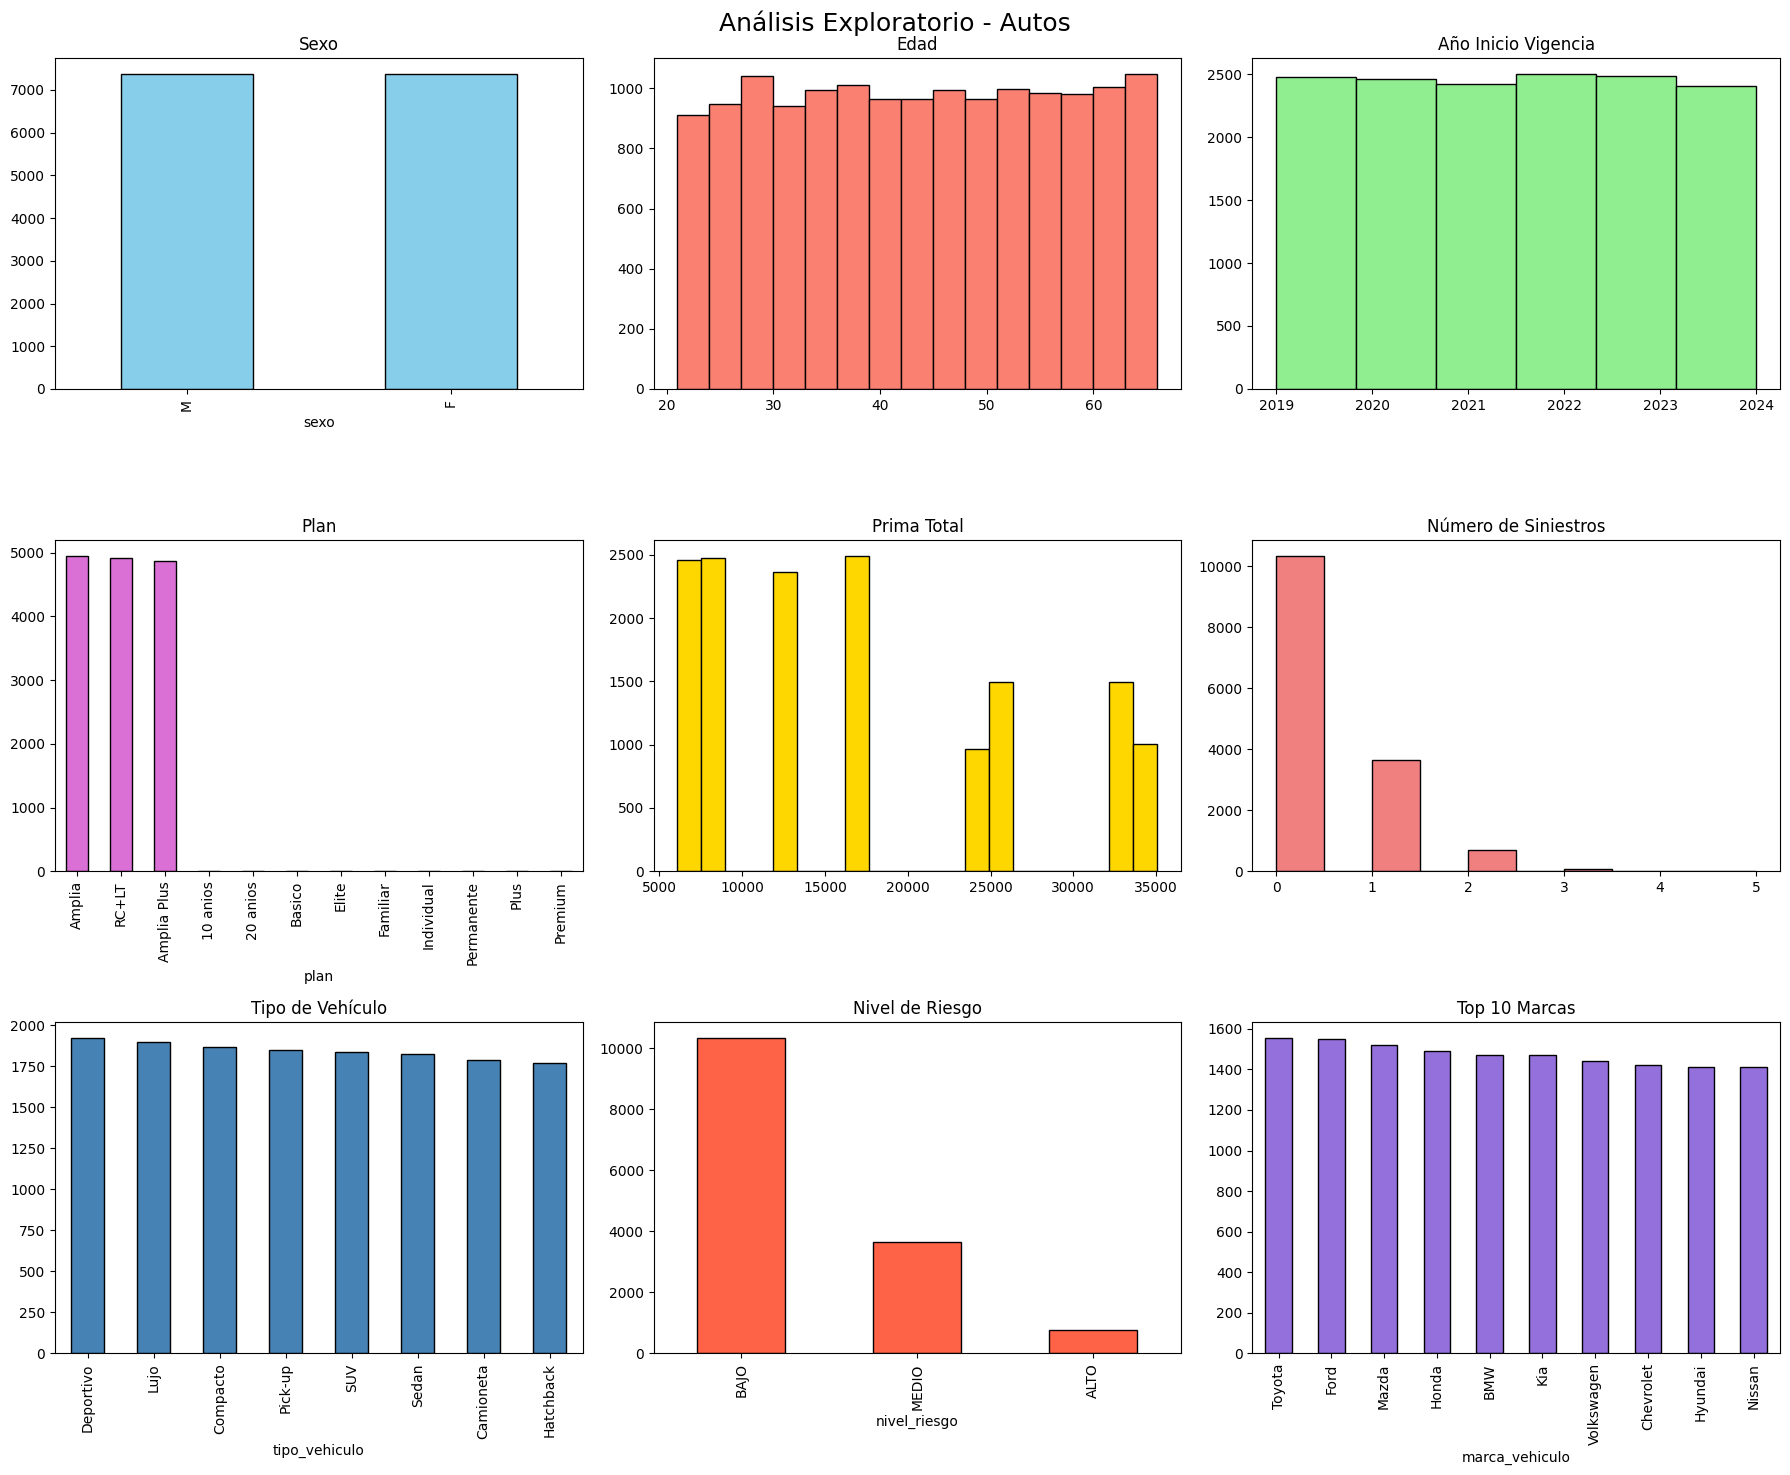

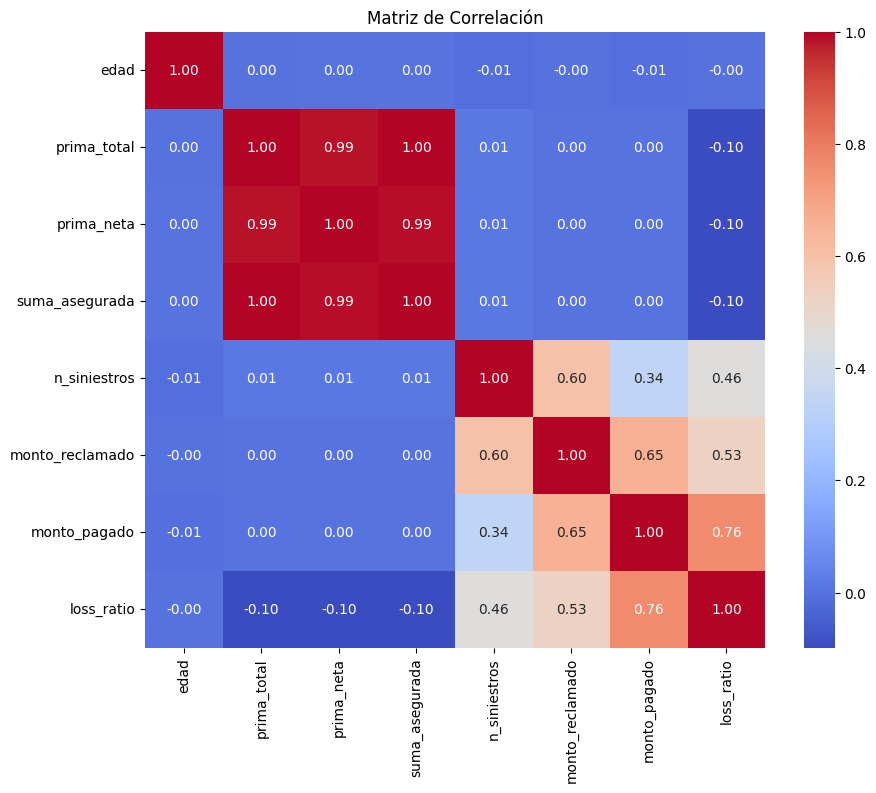

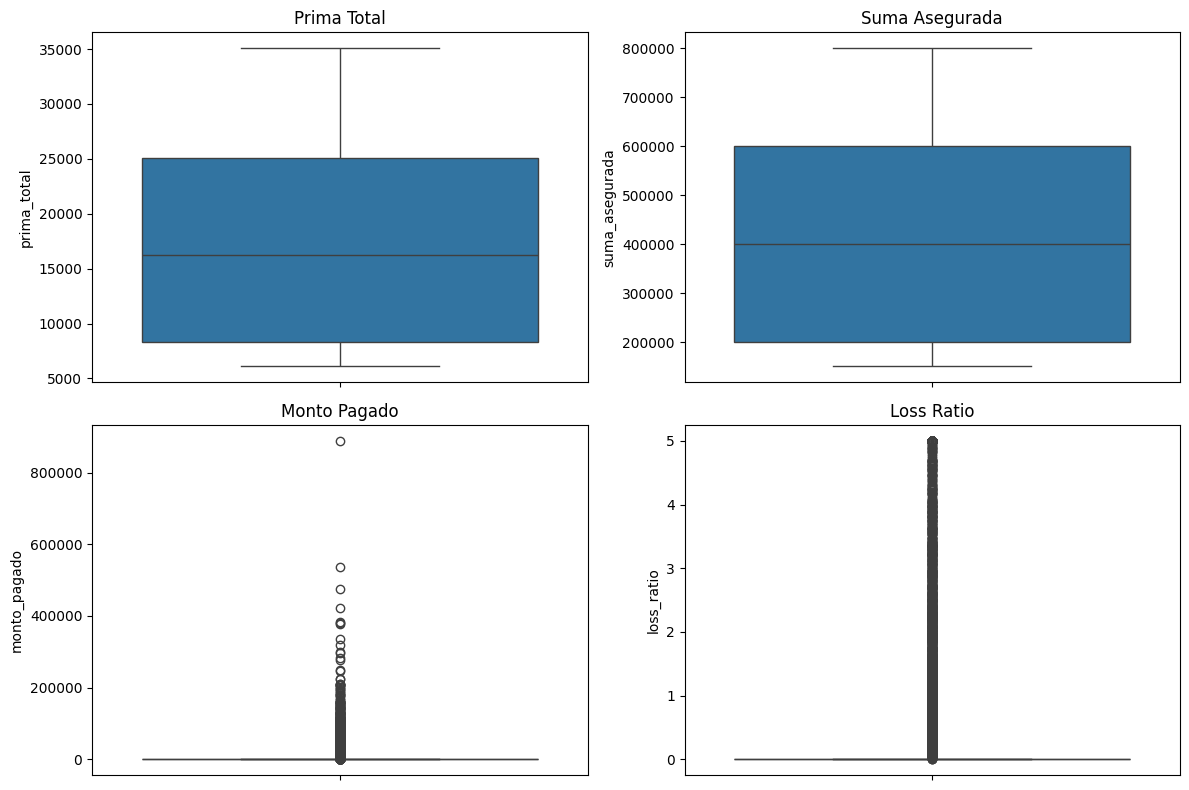


Variable: prima_total
Q1: 8363.6
Q3: 25090.8
IQR: 16727.199999999997
Outliers encontrados: 0

Variable: monto_pagado
Q1: 0.0
Q3: 0.0
IQR: 0.0
⚠️ Distribución degenerada (muchos ceros). Usando percentil 95 en su lugar.
Outliers encontrados: 738

Variable: loss_ratio
Q1: 0.0
Q3: 0.0
IQR: 0.0
⚠️ Distribución degenerada (muchos ceros). Usando percentil 95 en su lugar.
Outliers encontrados: 738


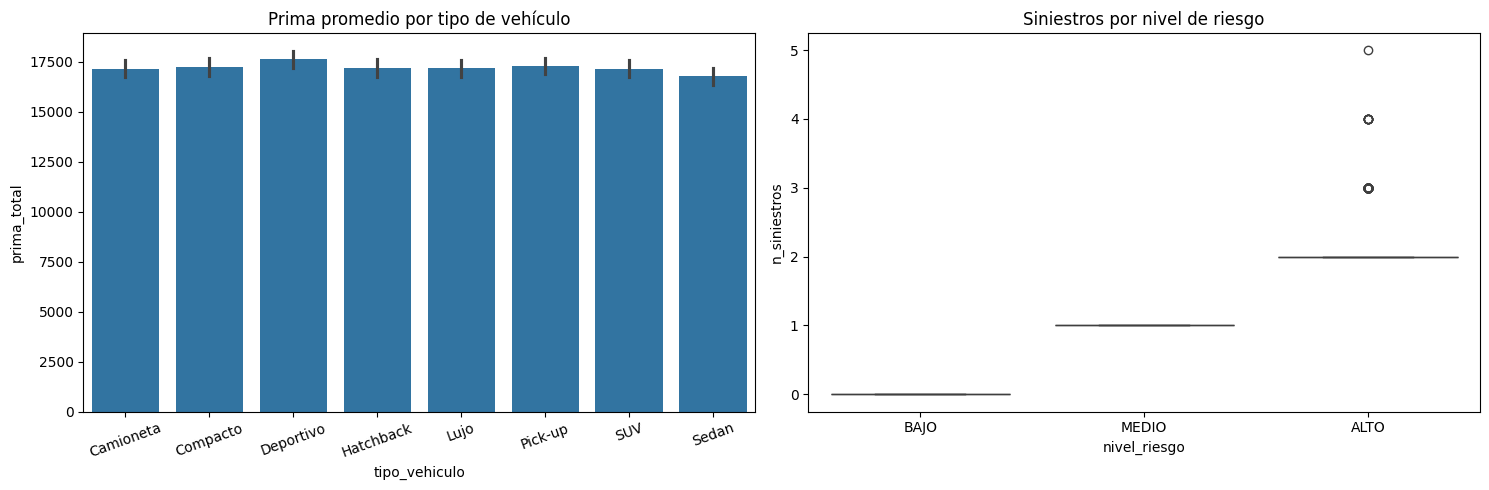

In [10]:
# Crear objeto
autos = AnalizadorRamo(cartera, 'Autos')

# Estadísticas generales
display(autos.calcular_estadisticas())

# Estadísticas descriptivas
display(autos.estadisticas_numericas())

# Distribuciones
autos.graficar()

# Correlaciones
autos.matriz_correlacion()

# Valores atípicos (boxplots)
autos.boxplots()

# Cantidad de valores atípicos
autos.detectar_outliers('prima_total')
autos.detectar_outliers('monto_pagado')
autos.detectar_outliers('loss_ratio')

# Análisis adicional
autos.analisis_adicional()